# Classification Tutorial (Lexos)

This notebook walks through: loading text files, scrubbing & tokenizing, constructing a document-term matrix (DTM), and training a classifier (including a Decision Tree). Each code cell below is now preceded by an explanation cell like this one so you can understand the workflow step by step.

### Prerequisites
Before running the code below, ensure:
- You installed the project in editable mode: `pip install -e .`
- spaCy model installed: `python -m spacy download en_core_web_sm`
- Kernel uses the same virtual environment (`sys.executable` matches your shell).

If `import lexos` fails, restart the kernel after installation.

### 1. Imports & Environment Setup
Import core Python utilities plus Lexos modules for loading (optional), scrubbing text, tokenizing, building a DTM, and classification. If an import fails, ensure the package is installed in the active environment.

In [20]:
from pathlib import Path
from lexos.io.loader import Loader
from lexos.scrubber.scrubber import Scrubber
from lexos.tokenizer import Tokenizer
from lexos.dtm import DTM, Vectorizer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

### 2. File Discovery
Recursively collect all `.txt` files under `sample_files`. This replaces earlier path assumptions (e.g., `essays/`). Adjust `candidate_dir` if your data lives elsewhere. Empty result → downstream steps will fail.

In [21]:
#find all .txt files in subfolders
files = list(Path("sample_files/essays").rglob("*.txt"))

### 3. Scrubber Pipeline Setup
Configure a text cleaning pipeline (lowercasing, digit removal, limited punctuation removal). This normalizes inputs before tokenization. Adjust or extend components to suit your task.

In [22]:
scrubber = Scrubber()
scrubber.add_pipe("lower_case")
scrubber.add_pipe("digits")
scrubber.add_pipe("punctuation")


### 4. Tokenization & Feature Label Prep
Tokenize cleaned text into spaCy Docs, then extract plain token strings filtering whitespace/punct/digits. Build per-document token lists plus two label lists:
- `labels`: unique document identifiers (filenames)
- `y`: target class (parent folder name)
Both are required: `labels` for DTM indexing, `y` for supervised learning.

#### Tokenizer API Note
You can obtain tokens three equivalent ways:
1. tokenizer.make_doc(text) -> Doc
2. tokenizer([text1, text2, ...]) -> generator of Doc objects (batch)
3. Direct call tokenizer(text) (same as make_doc)

In examples below we standardize on calling tokenizer(text) for clarity; any approach is fine.

In [23]:
tokenizer = Tokenizer(model="en_core_web_sm")

In [24]:
token_lists = []
labels = []
y = []

for f in files:
    raw = f.read_text(encoding="utf-8")
    clean = scrubber.scrub(raw)
    # Direct call style also works: doc = tokenizer(clean)
    doc = tokenizer.make_doc(clean)
    tokens = [token.text for token in doc]
    token_lists.append(tokens)
    labels.append(f.name)            # for DTM
    y.append(f.parent.name)          # for classification


### 5. Diagnostic Sanity Checks
Before building the DTM, confirm non-empty documents and consistent lengths between token lists and labels. Early assertions save time debugging downstream errors.

In [25]:
from pathlib import Path
print("CWD:", Path.cwd())
print("Number of raw files found:", len(files))
print("First 3 file paths:", files[:3])

print("token_lists type:", type(token_lists))
print("Number of tokenized docs:", len(token_lists))
print("labels len:", len(labels), "y len:", len(y))

if token_lists:
    print("First doc token count:", len(token_lists[0]))
    print("Sample tokens:", token_lists[0][:15])
else:
    print("token_lists is EMPTY")

CWD: c:\Users\gabal\OneDrive\Lexos_Independant_Research\uv_lexos\doc_src\docs\tutorials\classification
Number of raw files found: 0
First 3 file paths: []
token_lists type: <class 'list'>
Number of tokenized docs: 0
labels len: 0 y len: 0
token_lists is EMPTY


In [26]:
from pathlib import Path

# Robust file discovery relative to this notebook
base = Path.cwd()  # should be .../classification
candidate_dir = base / "sample_files"
files = sorted(candidate_dir.rglob("*.txt"))

print("Base:", base)
print("Sample dir exists:", candidate_dir.exists())
print("Files found:", len(files))
print("First 5:", files[:5])

if not files:
    raise FileNotFoundError(
        "No .txt files found. Check working directory or adjust path.\n"
        f"Tried: {candidate_dir}\n"
        "If running from project root, use: Path('doc_src/docs/tutorials/classification/sample_files').rglob('*.txt')"
    )

Base: c:\Users\gabal\OneDrive\Lexos_Independant_Research\uv_lexos\doc_src\docs\tutorials\classification
Sample dir exists: True
Files found: 80
First 5: [WindowsPath('c:/Users/gabal/OneDrive/Lexos_Independant_Research/uv_lexos/doc_src/docs/tutorials/classification/sample_files/Hamilton/essay01.txt'), WindowsPath('c:/Users/gabal/OneDrive/Lexos_Independant_Research/uv_lexos/doc_src/docs/tutorials/classification/sample_files/Hamilton/essay06.txt'), WindowsPath('c:/Users/gabal/OneDrive/Lexos_Independant_Research/uv_lexos/doc_src/docs/tutorials/classification/sample_files/Hamilton/essay07.txt'), WindowsPath('c:/Users/gabal/OneDrive/Lexos_Independant_Research/uv_lexos/doc_src/docs/tutorials/classification/sample_files/Hamilton/essay08.txt'), WindowsPath('c:/Users/gabal/OneDrive/Lexos_Independant_Research/uv_lexos/doc_src/docs/tutorials/classification/sample_files/Hamilton/essay09.txt')]


In [27]:
token_lists, labels, y = [], [], []

for f in files:
    raw = f.read_text(encoding="utf-8")
    clean = scrubber.scrub(raw)
    # Show alternative direct-call usage for variety
    doc = tokenizer(clean)
    tokens = [t.text for t in doc if t.text.strip()]
    token_lists.append(tokens)
    labels.append(f.name)          # unique doc id
    y.append(f.parent.name)        # class = folder (Hamilton/Jay/Madison)

print("Docs:", len(token_lists), "Labels:", len(labels), "Targets:", len(y))
assert len(token_lists) > 0
assert len(token_lists) == len(labels) == len(y)

KeyboardInterrupt: 

In [ ]:
if not token_lists:
    raise RuntimeError("token_lists empty: confirm file discovery cell ran and found files.")

### 6. Build the DTM (Document-Term Matrix)
Create a sparse matrix representation of term frequencies using Lexos `DTM` + `Vectorizer`. This matrix (X) is the feature input for classifiers. `labels` aligns row order → ensure ordering matches earlier token processing.

In [ ]:
# Build the Document-Term Matrix (DTM)
# Using the collected token_lists and labels from earlier steps
from lexos.dtm import DTM, Vectorizer

dtm = DTM(vectorizer=Vectorizer())
X = dtm(docs=token_lists, labels=labels)
X = dtm.doc_term_matrix
print("DTM shape:", X.shape)
print("Vocabulary size:", len(dtm.sorted_terms_list))

DTM shape: (80, 8335)
Vocabulary size: 8335


### 9b. Decision Tree Classifier with Feature Importance
Train a Decision Tree (interpretable splits) using the same DTM. Then inspect the top terms influencing decisions.

The `trainer.train_classifier()` function streamlines model training and evaluation. Key arguments include:

- `feature_matrix`: The DTM or feature array (X).
- `target_labels`: List/array of target classes (y).
- `model`: String specifying the classifier type (e.g., `"decision_tree"`, `"svc"`).
- `test_size`: Fraction of data for test split (e.g., `0.3`).
- `random_state`: Seed for reproducibility.
- Additional keyword arguments are passed to the underlying scikit-learn estimator.

Returns the fitted model and a classification report.

In [ ]:
# Train Decision Tree via helper
from lexos.classification import trainer

decision_tree_model, dt_report = trainer.train_classifier(
    feature_matrix=X,
    target_labels=y,
    model="decision_tree",
    test_size=0.3,
    random_state=42,
)
print(dt_report)

# Feature importance (top 20 terms)
import numpy as np, pandas as pd
importances = decision_tree_model.feature_importances_
if importances is not None and getattr(importances, 'size', 0):
    vocab_terms = dtm.sorted_terms_list
    top_idx = np.argsort(importances)[::-1][:20]
    fi_df = pd.DataFrame({
        'term': [vocab_terms[i] for i in top_idx],
        'importance': importances[top_idx]
    })
    fi_df
else:
    print("Model does not expose feature_importances_ (e.g., non-tree classifier).")

ValueError: Found input variables with inconsistent numbers of samples: [80, 0]

### 7. Train/Test Split + Decision Tree Training
Split the DTM feature matrix X and targets y into train/test sets, then fit a chosen classifier (`decision_tree` here). Returns fitted model + performance report (precision/recall/F1 per class).

Get stats of the .fit

Confusion matrix generated from a separately trained DecisionTreeClassifier.


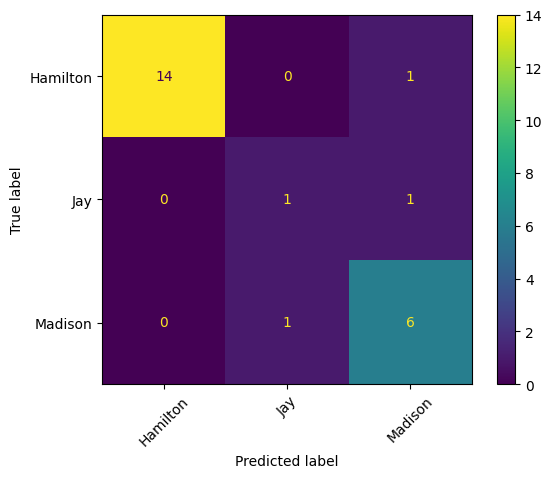

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# For a confusion matrix we need the test split used for evaluation.
# The helper trainer function hid the internal split, so we recreate a split
# and (re)train a fresh decision tree on that split for visualization purposes.
# This may yield slightly different metrics than the earlier helper report,
# but uses the same random_state for reproducibility.

X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y if len(set(y)) > 1 else None
)

cm_tree = DecisionTreeClassifier(random_state=42)
cm_tree.fit(X_train_dt, y_train_dt)
y_pred_dt = cm_tree.predict(X_test_dt)

labels_sorted = sorted(set(y))
cm = confusion_matrix(y_test_dt, y_pred_dt, labels=labels_sorted)

disp = ConfusionMatrixDisplay(cm, display_labels=labels_sorted)
disp.plot(xticks_rotation=45)
print("Confusion matrix generated from a separately trained DecisionTreeClassifier.")

### 10b. Confusion Matrix (Decision Tree)
Visualize classification performance across classes—helps spot systematic misclassifications.

In [ ]:
from lexos.classification import trainer

# Use the train_classifier function from trainer.py to train a decision tree
clf, report = trainer.train_classifier(
    feature_matrix=X,
    target_labels=y,
    model="decision_tree",
    test_size=0.3,
    random_state=42
)

print(report)

              precision    recall  f1-score   support

    Hamilton       1.00      0.93      0.97        15
         Jay       0.50      0.50      0.50         2
     Madison       0.75      0.86      0.80         7

    accuracy                           0.88        24
   macro avg       0.75      0.76      0.76        24
weighted avg       0.89      0.88      0.88        24



### 8. Evaluate Model & Inspect Predictions
Generate evaluation metrics and optionally inspect misclassifications or confusion matrix (extend here if needed).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# initialize classifier
clf = SVC(kernel="linear")  # or DecisionTreeClassifier(), LogisticRegression(), etc.

#train
clf.fit(X_train, y_train)

#predict
y_pred = clf.predict(X_test)

#evaluate
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

    Hamilton       1.00      0.94      0.97        17
         Jay       1.00      1.00      1.00         1
     Madison       0.86      1.00      0.92         6

    accuracy                           0.96        24
   macro avg       0.95      0.98      0.96        24
weighted avg       0.96      0.96      0.96        24



### 9. Train Alternative Model via scikit-learn Pipeline
Illustrates how to wrap a classifier (e.g., linear SVC) inside a pipeline for easier hyperparameter tuning / swapping compared to the helper function above.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

clf_pipeline = Pipeline([
    ("classifier", DecisionTreeClassifier())  # swap with SVC() or any other classifier
])

clf_pipeline.fit(X_train, y_train)
y_pred = clf_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

    Hamilton       1.00      1.00      1.00        17
         Jay       0.00      0.00      0.00         1
     Madison       0.80      0.67      0.73         6

    accuracy                           0.88        24
   macro avg       0.60      0.56      0.58        24
weighted avg       0.91      0.88      0.89        24



### 10. Persist Predictions (Optional Placeholder)
Demonstrates generating predictions on held-out data. You can save results with a helper (e.g., `save_predictions`) once integrated into the classification utilities.

### 11b. Predict on New Text
Demonstrate inference using existing scrubber, tokenizer, and shared vectorizer vocabulary.

In [ ]:
# Reuse earlier objects: scrubber, tokenizer, dtm (vectorizer), and trained decision_tree_model
new_text = "In this newly uncovered parchment, the king declares a festival of unity across the realm."

# 1. Scrub (Scrubber has a .scrub method, not .run)
clean_new = scrubber.scrub(new_text)
# 2. Tokenize (Tokenizer exposes make_doc / make_docs or can be called directly)
new_doc = tokenizer.make_doc(clean_new)
new_tokens = [t.text for t in new_doc if t.text.strip()]
# 3. Vectorize (must align with training vocabulary)
new_vec = dtm.vectorizer.transform([" ".join(new_tokens)])

pred_label = decision_tree_model.predict(new_vec)[0]
print(f"Predicted label: {pred_label}")
print("First 15 tokens:", new_tokens[:15])

Predicted label: Madison
First 15 tokens: ['in', 'this', 'newly', 'uncovered', 'parchment', 'the', 'king', 'declares', 'a', 'festival', 'of', 'unity', 'across', 'the', 'realm']


### 12b. Persist Model & Vocabulary
Use joblib (or pickle) to save the trained model and vectorizer for reuse without retraining.

In [ ]:
import joblib, os
os.makedirs("artifacts", exist_ok=True)
joblib.dump(decision_tree_model, "artifacts/decision_tree_model.joblib")
joblib.dump(dtm.vectorizer, "artifacts/vectorizer.joblib")
print("Saved: artifacts/decision_tree_model.joblib, artifacts/vectorizer.joblib")

# (Optional) later reload
reloaded_model = joblib.load("artifacts/decision_tree_model.joblib")
reloaded_vec = joblib.load("artifacts/vectorizer.joblib")
assert (reloaded_model.predict(new_vec)[0] == pred_label)

Saved: artifacts/decision_tree_model.joblib, artifacts/vectorizer.joblib


### 13. Common Pitfalls & Troubleshooting
- Empty DTM: Usually caused by filtering everything out (min_df too high) or passing empty token lists. Inspect a few tokenized docs.
- Inconsistent Vocabulary on Inference: Always reuse the original fitted vectorizer.
- Class Imbalance: Consider stratified splits and look at per-class recall.
- Overfitting Decision Trees: Adjust max_depth, min_samples_split, or try an ensemble (RandomForest, GradientBoosting).
- UnicodeDecodeError on Load: Pass encoding explicitly when reading raw files before building docs.
- spaCy Model Not Found: Install with `python -m spacy download en_core_web_sm` or use a blank tokenizer fallback.
- Reproducibility: Fix random_state for splits and classifier.
- Memory Issues: Limit max_n_terms or raise min_df to reduce feature space.


### 11. Full Pipeline Report
Show consolidated classification metrics and sample predictions. Extend here with confusion matrices, per-class F1 visualization, or feature importance (for tree-based models).

### 12. Cleanup / Next Steps
Consider persisting the trained model (joblib), exporting the DTM, or moving preprocessing steps into reusable functions. Explore hyperparameter tuning (GridSearchCV) and try alternative models (RandomForest, LogisticRegression) using the same DTM.